# Chapter 5 (5.1–5.3): Data Visualization & Storytelling  
This notebook covers:

- **5.1** Principles of good visualization (clarity, accuracy, storytelling)
- **5.2** Matplotlib fundamentals (line, bar, histogram, scatter, subplots)
- **5.3** Seaborn statistical plots (boxplot, pairplot, heatmap)

> **Goal:** pick the right chart for the question and avoid misleading visuals.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams["figure.figsize"] = (7, 4)

np.random.seed(7)


---  
## 5.1 Visualization Principles

### Principle 1: **Clarity beats decoration**
Compare a cluttered chart vs a clean chart using the same data.


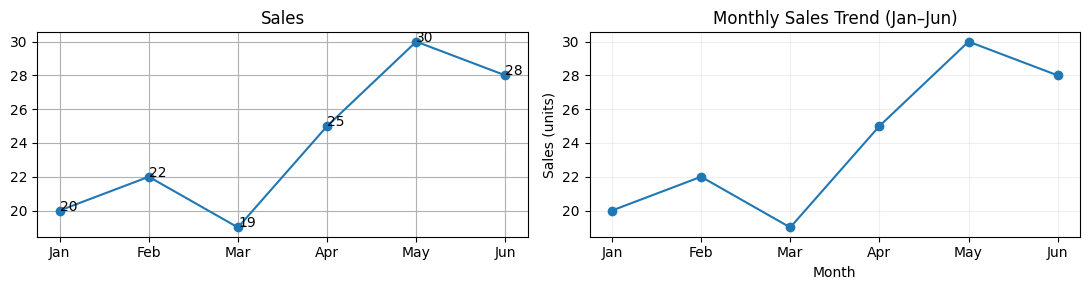

In [2]:
months = ["Jan","Feb","Mar","Apr","May","Jun"]
sales  = [20, 22, 19, 25, 30, 28]

fig, ax = plt.subplots(1, 2, figsize=(11, 3))

# BAD: clutter + unclear labeling
ax[0].plot(months, sales, marker="o")
ax[0].set_title("Sales")
ax[0].grid(True)
for i, v in enumerate(sales):
    ax[0].text(i, v, str(v))  # too many labels

# GOOD: clear question + minimal ink
ax[1].plot(months, sales, marker="o")
ax[1].set_title("Monthly Sales Trend (Jan–Jun)")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Sales (units)")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


**Try (quick):**
1. Remove the point labels from the left plot.
2. Add axis labels to the left plot.
3. Which plot communicates faster, and why?


### Principle 2: **Accuracy** (avoid misleading axes)
For **bar charts**, starting the y-axis far from zero can exaggerate differences.


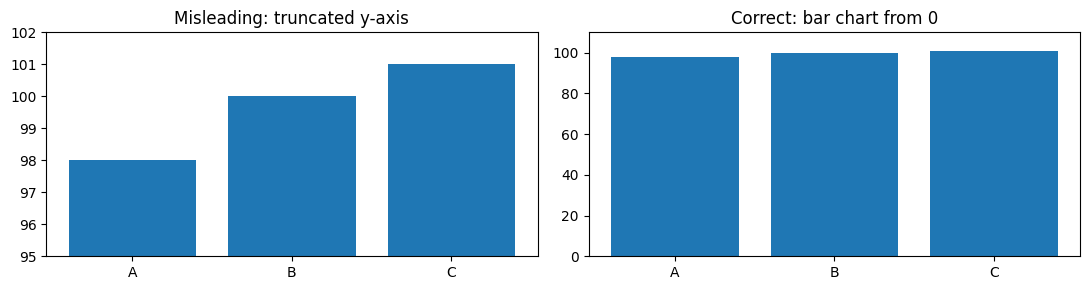

In [3]:
products = ["A", "B", "C"]
revenue  = [98, 100, 101]   # tiny differences

fig, ax = plt.subplots(1, 2, figsize=(11, 3))

ax[0].bar(products, revenue)
ax[0].set_ylim(95, 102)
ax[0].set_title("Misleading: truncated y-axis")

ax[1].bar(products, revenue)
ax[1].set_ylim(0, 110)
ax[1].set_title("Correct: bar chart from 0")

plt.tight_layout()
plt.show()


**Discuss:**  
- Which chart feels “more dramatic”?  
- Which chart is fair for a bar chart, and why?


### Mini-checklist for every chart  
Before you present a plot, ensure:
- A **meaningful title** (what question does it answer?)
- Clear **axis labels** + units
- Avoid clutter (only show what helps)
- The chart type matches the question


---  
## 5.2 Matplotlib Fundamentals

We’ll use one small dataset and answer four different questions:
- Trend over time? → line
- Compare categories? → bar
- Distribution? → histogram
- Relationship? → scatter


In [4]:
df = pd.DataFrame({
    "day": np.arange(1, 11),
    "sales": [12, 13, 15, 14, 18, 20, 19, 21, 24, 23],
    "ads":   [1,  2,  2,  3,  3,  4,  4,  5,  6,  6],
    "product": ["A","A","A","A","B","B","B","B","C","C"]
})
# df.describe()?


### 5.2.1 Same data, different charts (subplots)

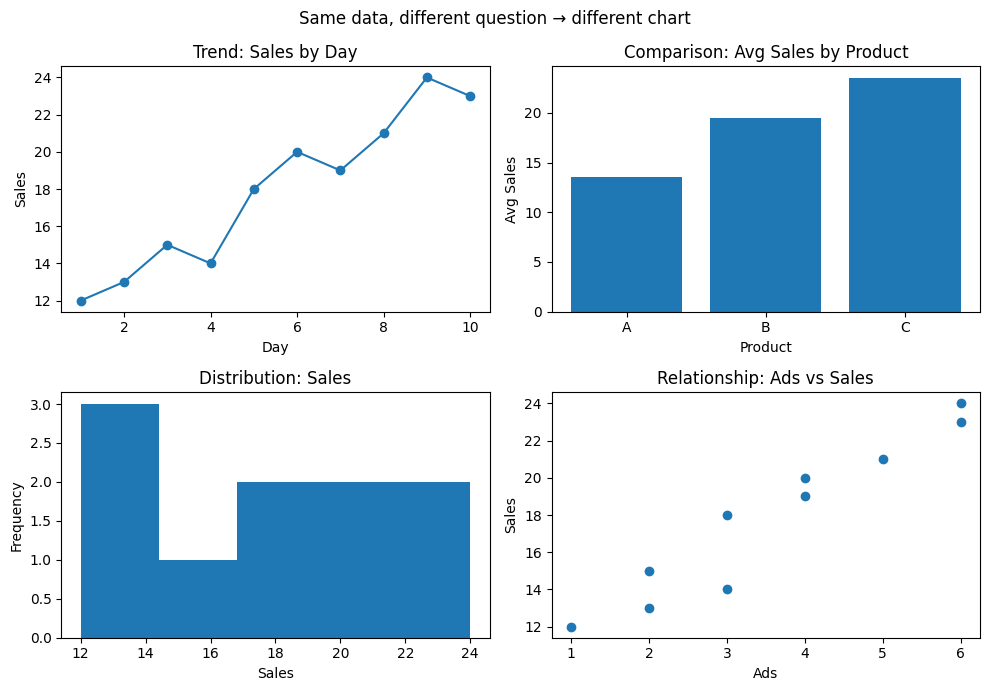

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Same data, different question → different chart", fontsize=12)

# Trend → line
ax[0,0].plot(df["day"], df["sales"], marker="o")
ax[0,0].set_title("Trend: Sales by Day")
ax[0,0].set_xlabel("Day"); ax[0,0].set_ylabel("Sales")

# Comparison → bar
avg_sales = df.groupby("product")["sales"].mean()
ax[0,1].bar(avg_sales.index, avg_sales.values)
ax[0,1].set_title("Comparison: Avg Sales by Product")
ax[0,1].set_xlabel("Product"); ax[0,1].set_ylabel("Avg Sales")

# Distribution → histogram
ax[1,0].hist(df["sales"], bins=5)
ax[1,0].set_title("Distribution: Sales")
ax[1,0].set_xlabel("Sales"); ax[1,0].set_ylabel("Frequency")

# Relationship → scatter
ax[1,1].scatter(df["ads"], df["sales"])
ax[1,1].set_title("Relationship: Ads vs Sales")
ax[1,1].set_xlabel("Ads"); ax[1,1].set_ylabel("Sales")

plt.tight_layout()
plt.show()


### 5.2.2 One-plot best practice (title + labels)
Make a plot “presentation-ready” in seconds.


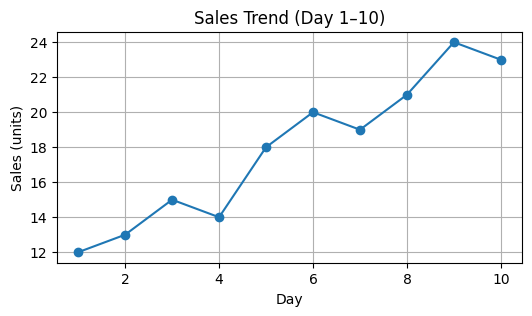

In [6]:
plt.figure(figsize=(6,3))
plt.plot(df["day"], df["sales"], marker="o")
plt.title("Sales Trend (Day 1–10)")
plt.xlabel("Day")
plt.ylabel("Sales (units)")
plt.grid(alpha=1)
# alpha is opacity. For plt.grid(alpha=...):

# alpha=0 → fully transparent, grid effectively invisible.
# alpha=1 → fully opaque, grid fully visible.
# Values in between (like 0.2) → faint grid that doesn’t distract.
plt.show()


### Exercise: Fix the chart (5–7 minutes)
The chart below is intentionally weak. Improve it:
1) Better title  
2) x/y labels  
3) Improve readability (size, grid alpha, rotate labels if needed)


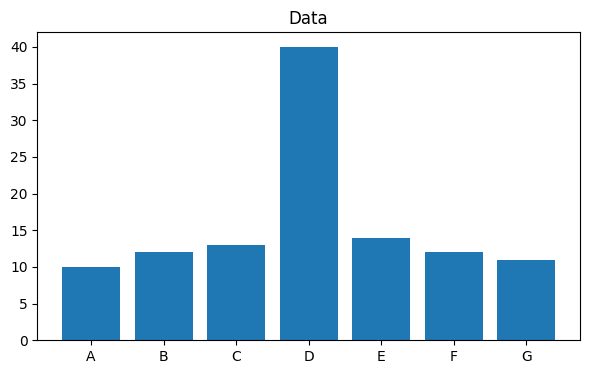

In [7]:
x = ["A","B","C","D","E","F","G"]
y = [10, 12, 13, 40, 14, 12, 11]

plt.bar(x, y)
plt.title("Data")
plt.show()


---  
## 5.3 Seaborn: Statistical Visualizations

Seaborn makes it easy to compare distributions and relationships with cleaner defaults.


### 5.3.1 Boxplot: spread + outliers

| Step | Expression |
|------|------------|
| 1 | `["HR"]*40` → `["HR", "HR", ..., "HR"]` (40 items) |
| 2 | `["Sales"]*40` → `["Sales", ..., "Sales"]` (40 items) |
| 3 | `["IT"]*40` → `["IT", ..., "IT"]` (40 items) |
| 4 | All three lists get concatenated with `+` → 120 items |

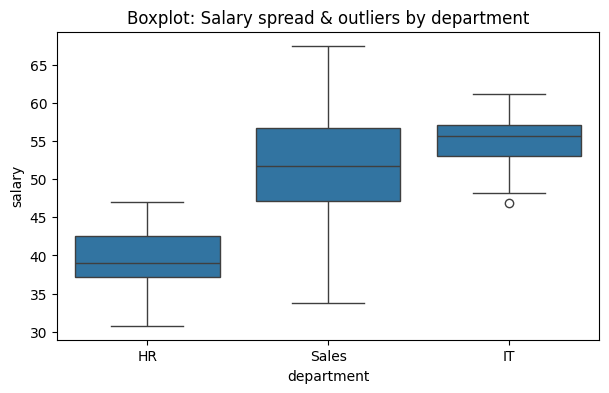

In [8]:
np.random.seed(1) # Ensures reproducibility—same "random" data every time.

df2 = pd.DataFrame({
    "department": (["HR"]*40) + (["Sales"]*40) + (["IT"]*40),
    "salary": np.concatenate([
        np.random.normal(40, 4, 40), # np.random.normal(mean, std, size)
        np.random.normal(50, 8, 40),
        np.random.normal(55, 5, 40),
    ])
})


plt.figure(figsize=(7,4))
sns.boxplot(data=df2, x="department", y="salary")
plt.title("Boxplot: Salary spread & outliers by department")
plt.show()


In [9]:
# salary = ["HR"]*40 + ["Sales"]*40 + ["IT"]*40

**Quick prompts:**  
- Which department has the widest spread?  
- Do you see outliers? What could cause them (data error vs real case)?


In [10]:
["12"]*12 + ["343"]

['12', '12', '12', '12', '12', '12', '12', '12', '12', '12', '12', '12', '343']

### 5.3.2 Pairplot: relationships across multiple variables

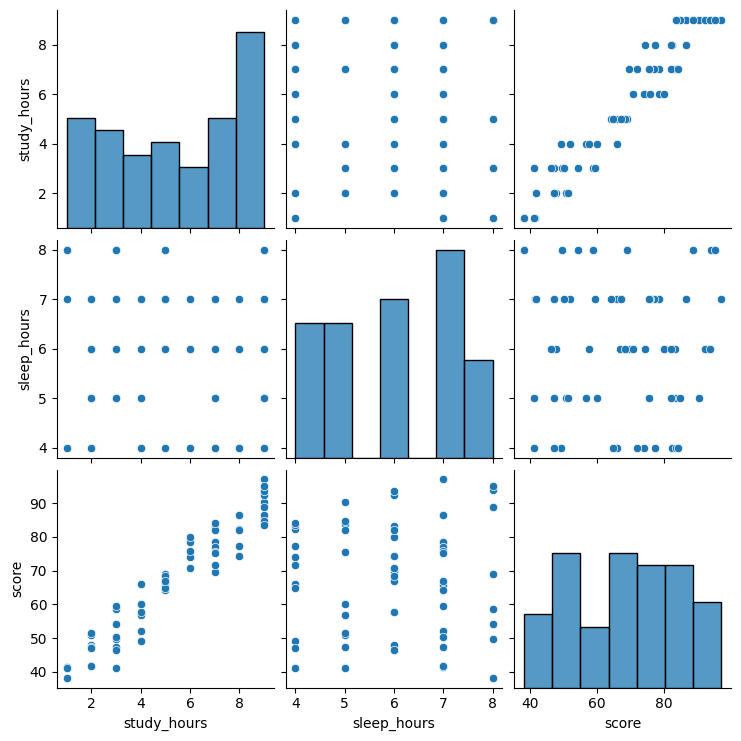

In [11]:
np.random.seed(2)

df3 = pd.DataFrame({
    "study_hours": np.random.randint(1, 10, 60),
    "sleep_hours": np.random.randint(4, 9, 60),
})
df3["score"] = 35 + df3["study_hours"]*6 + np.random.normal(0, 6, 60)

sns.pairplot(df3)
plt.show()


### 5.3.3 Heatmap: correlation matrix

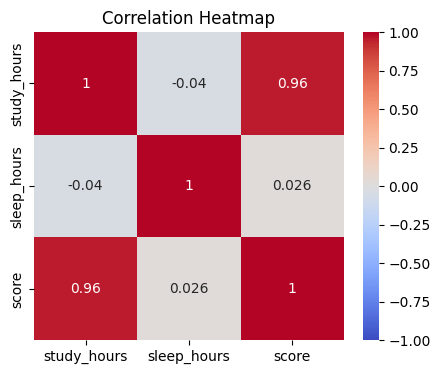

In [ ]:
# Calculate correlation matrix (Pearson correlation between all numeric columns)
# Values range from -1 (perfect negative) to +1 (perfect positive), 0 = no correlation
corr = df3.corr(numeric_only=True)

plt.figure(figsize=(5,4))

# Create heatmap visualization
# annot=True      → show numeric values in each cell
# vmin=-1, vmax=1 → fix color scale to standard correlation range
# cmap="coolwarm" → blue=negative, white=zero, red=positive
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## Correlation ≠ Causation


**Correlation** = Two things happen together  
**Causation** = One thing **makes** the other happen

---

### Simple Example

☀️ **Hot weather** causes:
- 🍦 More ice cream sales
- 🏊 More people swimming → more drownings

**Ice cream sales** and **drownings** are correlated (both go up in summer), but ice cream doesn't **cause** drowning!

---

### The Point

Just because A and B move together doesn't mean:
- A causes B
- B causes A

There might be a **hidden C** causing both!

---

### Remember

> *"People who carry lighters are more likely to get lung cancer."*  
> Does the lighter cause cancer? **No!** — Smoking is the hidden factor.

---  
## Quick Practice
1) Using `df`, make a scatter plot of `day` vs `sales`. Is that a meaningful relationship?  
2) Using `df2`, change the y-axis label to include units (e.g., “Salary (k$)”).  
3) Using `df3`, try adding a new column: `screen_time` and see how it changes the heatmap.
